[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/takechanman1228/marketing-science-in-python/blob/main/notebooks/part4-customer-analytics/sec4.1_semantic_segmentation.ipynb)

# Embedding-Based Customer Segmentation with BERTopic

This notebook accompanies **§4.1** of *Marketing Science in Python*
(Modern Methods section). We use **BERTopic**, which wraps SentenceTransformers,
UMAP, and HDBSCAN into a single pipeline, to discover customer segments from
product purchase text, then interpret them with an LLM.

For traditional methods (decile, RFM, K-Means, GMM), see the companion script
`sec4.1_traditional_segmentation.py`.

**Dataset**: UCI Online Retail II (Kaggle, CC0). ~1M transaction rows from a
UK-based online retailer, with product descriptions.

**Learning objectives**

1. Build revenue-weighted customer documents from product descriptions for
   embedding-based segmentation (after filtering generic, ubiquitous SKUs).
2. Use BERTopic to discover semantic customer segments and **collapse them
   down to 4–8 operational segments** with `reduce_topics()`.
3. Reduce outliers so every customer carries a usable topic label.
4. Automate segment naming with an LLM, then **validate the names against
   keyword and RFM evidence** — the "LLM-naming trap" in the chapter.
5. Compare HDBSCAN's discovery segments with KMeans-on-embeddings for
   activation, and score a held-out customer with `transform()`.
6. Honestly assess temporal stability (ARI) on a time-split holdout.

**Required packages**: `bertopic`, `sentence-transformers`, `umap-learn`,
`hdbscan`, `litellm`, `anthropic` (for LLM segment naming via Claude).

**LLM naming is optional**: set `ANTHROPIC_API_KEY` in your environment to get
LLM-generated segment names; without it the notebook falls back to c-TF-IDF keywords.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.feature_extraction.text import CountVectorizer

In [2]:
# Colab bootstrap: make the `msbook` helper package importable.
# Local / conda users already have it via `pip install -e .` from the repo root,
# so this is a no-op for them. On Colab it clones the book repo and installs
# msbook in editable mode. (A plain `pip install git+...` is not enough: msbook
# resolves paths by walking up to the repo's _quarto.yml, so it needs the repo
# tree present, which the clone provides.)
import sys
try:
    import msbook  # noqa: F401
except ModuleNotFoundError:
    import subprocess
    _REPO = "https://github.com/takechanman1228/marketing-science-in-python.git"
    subprocess.run(["git", "clone", "-q", _REPO], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e",
                    "marketing-science-in-python"], check=True)
    import msbook  # noqa: F401
from msbook.data import load_online_retail_ii

CONFIG = {
    "top_n_products": 20,
    "min_topic_size": 15,       # HDBSCAN min size — loose so we find many initial topics
    "min_cluster_size": 15,     # HDBSCAN min_cluster_size matches min_topic_size
    "min_samples": 3,           # HDBSCAN min_samples
    "umap_n_components": 5,     # UMAP target dims for clustering
    "umap_n_neighbors": 15,     # smaller neighborhood — preserves local structure
    "embedding_model": "all-MiniLM-L6-v2",
    "random_state": 42,
    "generic_product_threshold": 0.03,  # tighter: drop SKUs bought by >3% of customers
    "nr_topics": 8,             # target final segment count (chapter: 4–8 segments)
    "min_segment_share": 0.10,  # chapter target: each segment ≥ 10% of base
    "mega_subsegments": 6,      # if a mega-topic forms, sub-decompose with KMeans into this many
    "mega_threshold": 0.50,     # any topic > 50% of base triggers sub-decomposition
    "kmeans_k": 7,              # K for the balanced KMeans-on-embeddings comparison
                                # (a midpoint of the chapter's 4–8 practical range)
    # --- data cleaning ---
    "non_product_codes": {"POST","DOT","M","D","S","C2","CRUK","AMAZONFEE","ADJUST","BANK"},
    "custom_stop_words": ["set","pack","pcs","piece","pieces","assorted","asstd","design","designs"],
    "doc_weight_k": 3,          # log-revenue repetition factor
    "vectorizer_min_df": 2,     # kill hapax legomena
    # --- LLM naming (Anthropic via litellm) ---
    "llm_model": "anthropic/claude-haiku-4-5",
    "llm_nr_docs": 8,           # docs sampled per topic for naming
    "llm_delay_seconds": 1,
}

ACCENT_BLUE = "#2171b5"
ACCENT_ORANGE = "#e6550d"
ACCENT_GREEN = "#31a354"
ACCENT_PURPLE = "#756bb1"
ACCENT_GREY = "#969696"

pd.set_option("display.float_format", "{:.2f}".format)

try:
    display
except NameError:
    display = print

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.facecolor": "white",
})

from msbook.paths import chapter_images, chapter_artifacts

_FIG_DIR = chapter_images(part="4", chapter="sec4.1")
_TABLES  = chapter_artifacts(part="4", chapter="sec4.1-segmentation") / "tables"
_TABLES.mkdir(parents=True, exist_ok=True)


def savefig(fig, name, **kw):
    kw.setdefault("dpi", 150)
    kw.setdefault("bbox_inches", "tight")
    fig.savefig(_FIG_DIR / name, **kw)

_step = 0

def step(title):
    global _step
    _step += 1
    print(f"\n{'='*60}")
    print(f"  Step {_step}: {title}")
    print(f"{'='*60}\n")

In [3]:
# Static figures for the published notebook: GitHub renders .ipynb without
# executing JavaScript, so interactive plotly output (the BERTopic
# visualizations below) would be invisible there. When this notebook is
# re-executed locally / in CI, emit plotly figures as static PNGs (via
# kaleido) so the committed outputs show on GitHub. On Colab, keep the
# default interactive renderer.
import importlib.util

if "google.colab" not in sys.modules and importlib.util.find_spec("kaleido"):
    import plotly.io as pio

    pio.renderers.default = "png"
    pio.renderers["png"].scale = 2

In [4]:
step("Load and clean UCI Online Retail II")

raw = load_online_retail_ii(clean=False)  # resolves data/raw/Online_Retail_II_UCI/
print(f"Raw rows: {len(raw):,}")
print(f"Columns: {list(raw.columns)}")

# Rename for consistency
raw = raw.rename(columns={"Customer ID": "CustomerID"})

# Parse dates
raw["InvoiceDate"] = pd.to_datetime(raw["InvoiceDate"], errors="coerce")
raw["CustomerID"] = pd.to_numeric(raw["CustomerID"], errors="coerce")

# Remove exact duplicate rows (3.2% of data)
n_before = len(raw)
raw = raw.drop_duplicates()
print(f"Dropped {n_before - len(raw):,} exact duplicates ({(n_before - len(raw))/n_before:.1%})")

# Clean: remove returns, cancelled invoices, missing IDs, non-product items
raw = raw[(raw["Quantity"] > 0) & (raw["Price"] > 0)]
raw = raw.dropna(subset=["CustomerID", "Description", "InvoiceDate"])
raw = raw[~raw["Invoice"].astype(str).str.startswith("C")]

# StockCode filter: remove non-product codes (POST, DOT, M, D, S, C2, etc.)
non_product = CONFIG["non_product_codes"]
n_before_sc = len(raw)
raw = raw[~raw["StockCode"].astype(str).isin(non_product)]
print(f"Removed {n_before_sc - len(raw):,} non-product rows (StockCodes: {non_product})")

# Description regex as safety net (catches remaining junk not in StockCode list).
# Word-boundary match only, and we match "POSTAGE" but NOT a bare "POST": the
# substring "POST" would kill real products ("POSTCARD", "POST OFFICE CABINET",
# "EGG HUNT START POST"), and the postage junk is already caught by "POSTAGE"
# plus the StockCode filter above. ADJUST\w* covers ADJUST / ADJUSTMENT(S).
# We print what was dropped so the filter can be eyeballed.
_JUNK_RE = (
    r"\b(?:POSTAGE|DOTCOM|CRUK|BANK CHARGES|MANUAL|DISCOUNT|"
    r"AMAZON|ADJUST\w*|TEST|SAMPLES?)\b"
)
junk_mask = raw["Description"].str.contains(_JUNK_RE, case=False, na=False, regex=True)
_removed = raw.loc[junk_mask, "Description"].value_counts()
print(f"Safety net removed {int(junk_mask.sum()):,} rows / "
      f"{len(_removed)} unique descriptions (top 10):")
print(_removed.head(10).to_string())
raw = raw[~junk_mask]
raw["Revenue"] = raw["Quantity"] * raw["Price"]
raw["CustomerID"] = raw["CustomerID"].astype(int)

print(f"\nAfter cleaning: {len(raw):,} rows  |  {raw['CustomerID'].nunique():,} customers")
print(f"Date range: {raw['InvoiceDate'].min()} to {raw['InvoiceDate'].max()}")
print(f"Unique products (StockCodes): {raw['StockCode'].nunique():,}")


  Step 1: Load and clean UCI Online Retail II



Raw rows: 1,067,371
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


Dropped 34,335 exact duplicates (3.2%)


Removed 2,785 non-product rows (StockCodes: {'AMAZONFEE', 'D', 'S', 'CRUK', 'BANK', 'M', 'POST', 'ADJUST', 'C2', 'DOT'})


Safety net removed 44 rows / 4 unique descriptions (top 10):
Description
Bank Charges                           29
This is a test product.                10
Adjustment by Peter on Jun 25 2010      3
 Bank Charges                           2

After cleaning: 776,596 rows  |  5,852 customers
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00
Unique products (StockCodes): 4,621


In [5]:
step("Feature engineering: RFM + customer documents")

ref_date = raw["InvoiceDate"].max() + pd.Timedelta(days=1)

# Per-customer RFM features (for profiling later) -- uses ALL purchases
uci_customers = (
    raw.groupby("CustomerID")
    .agg(
        recency=("InvoiceDate", lambda x: (ref_date - x.max()).days),
        frequency=("Invoice", "nunique"),
        monetary=("Revenue", "sum"),
        n_products=("StockCode", "nunique"),
    )
    .reset_index()
)
uci_customers["avg_order_value"] = uci_customers["monetary"] / uci_customers["frequency"]
print(f"UCI customers: {len(uci_customers):,}")
display(uci_customers.describe().round(2))

uci_customers.to_csv(_TABLES / "modern_uci_customer_features.csv", index=False)

# ── Filter generic products by StockCode (catches typos/variants) ──
# Products bought by >10% of customers dominate embeddings and create
# a single mega-topic.  We remove them from the document text only;
# RFM features above still use all purchases.
code_cust_counts = raw.groupby("StockCode")["CustomerID"].nunique()
n_total = raw["CustomerID"].nunique()
threshold = CONFIG["generic_product_threshold"]
generic_codes = set(
    code_cust_counts[code_cust_counts > threshold * n_total].index
)
print(f"\nGeneric products filtered by StockCode (>{threshold:.0%} of customers): "
      f"{len(generic_codes)}")
if generic_codes:
    # Show sample descriptions for the filtered codes
    sample = (raw[raw["StockCode"].isin(generic_codes)]
              .drop_duplicates("StockCode")[["StockCode","Description"]]
              .sort_values("StockCode"))
    for _, row in sample.head(10).iterrows():
        print(f"  - {row['StockCode']}: {row['Description']}")
    if len(generic_codes) > 10:
        print(f"  ... and {len(generic_codes) - 10} more")
raw_filtered = raw[~raw["StockCode"].isin(generic_codes)]

# ── Normalize descriptions ──
# Lowercase + strip packaging stop words to collapse "SET OF 3" / "set of 3"
import re
stop_pat = re.compile(
    r"\b(" + "|".join(re.escape(w) for w in CONFIG["custom_stop_words"]) + r")\b",
    re.IGNORECASE,
)
raw_filtered = raw_filtered.copy()
raw_filtered["Description"] = (
    raw_filtered["Description"]
    .str.lower()
    .str.replace(stop_pat, "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# ── Build revenue-weighted customer documents ──
# A numeric model sees only frequency/spend; this text lets the embedding
# model read product meaning.
TOP_N = CONFIG["top_n_products"]
K = CONFIG["doc_weight_k"]

prod_rev = (
    raw_filtered.groupby(["CustomerID", "Description"])["Revenue"]
    .sum()
    .reset_index()
    .sort_values(["CustomerID", "Revenue"], ascending=[True, False])
)
top_products = prod_rev.groupby("CustomerID").head(TOP_N)

# Revenue-weighted repetition: high-revenue products repeat more in the doc
def build_weighted_doc(grp):
    parts = []
    for _, row in grp.iterrows():
        repeat = 1 + int(np.log1p(row["Revenue"]) / K)
        parts.extend([row["Description"]] * repeat)
    return ", ".join(parts)

customer_docs = (
    top_products.groupby("CustomerID")
    .apply(build_weighted_doc)
    .reset_index()
    .rename(columns={0: "doc"})
)

print(f"\nCustomer documents: {len(customer_docs):,}")
print(f"\nExample document (CustomerID={customer_docs.iloc[0]['CustomerID']}):")
print(customer_docs.iloc[0]["doc"][:300] + "...")


  Step 2: Feature engineering: RFM + customer documents



UCI customers: 5,852


,CustomerID,recency,frequency,monetary,n_products,avg_order_value
count,5852.00,5852.00,5852.00,5852.00,5852.00,5852.00
mean,15319.71,200.20,6.25,2916.71,82.19,384.40
std,1714.93,208.51,12.75,14306.87,116.50,1254.73
min,12346.00,1.00,1.00,2.95,1.00,2.95
25%,13837.75,25.00,1.00,339.58,19.00,176.14
50%,15320.50,95.00,3.00,856.02,45.00,277.87
75%,16802.25,379.00,7.00,2241.03,103.00,410.56
max,18287.00,739.00,373.00,580987.04,2546.00,84236.25



Generic products filtered by StockCode (>3% of customers): 897
  - 10135: COLOURING PENCILS BROWN TUBE
  - 15036: ASSORTED COLOURS SILK FAN
  - 15056BL: EDWARDIAN PARASOL BLACK
  - 15056N: EDWARDIAN PARASOL NATURAL
  - 15056P: EDWARDIAN PARASOL PINK
  - 16156S: WRAP PINK FAIRY CAKES 
  - 16161P: WRAP ENGLISH ROSE 
  - 16161U: WRAP,SUKI AND FRIENDS
  - 16237: SLEEPING CAT ERASERS
  - 17003: BROCADE RING PURSE 
  ... and 887 more



Customer documents: 5,580

Example document (CustomerID=12346):
medium ceramic top storage jar, medium ceramic top storage jar, medium ceramic top storage jar, medium ceramic top storage jar, doormat christmas village, doormat i love london, doormat peace on earth blue, doormat welcome sunrise...


## Why BERTopic?

The manual embedding-based segmentation pipeline requires chaining four
independent libraries: SentenceTransformers (embed), UMAP (reduce),
HDBSCAN (cluster), and custom code (interpret). **BERTopic** wraps all
four into a single API and adds:

- **c-TF-IDF** for automatic keyword extraction per topic
- **Built-in visualizations** (document scatter, hierarchy, barchart)
- **LLM representation models** for automated topic/segment naming
- **`transform()`** for scoring new documents without refitting
- **`reduce_outliers()`** for handling the noise problem HDBSCAN creates

| Layer | Tool | Role |
|---|---|---|
| All-in-one | **BERTopic** | Wraps embedding + UMAP + HDBSCAN + c-TF-IDF |
| Embedding | SentenceTransformers | Text → dense vectors (pluggable) |
| Interpretation | LiteLLM + Claude | Segment naming via LLM |
| Scale (optional) | Faiss, Vector DB | Production nearest-neighbor |

In [6]:
step("Fit BERTopic model")

from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from bertopic.representation import KeyBERTInspired
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN

# A local SentenceTransformers model keeps this reproducible; the same
# pipeline accepts an API embedding model (e.g. OpenAI) by swapping this line.
embedding_model = SentenceTransformer(CONFIG["embedding_model"])
embeddings = embedding_model.encode(
    customer_docs["doc"].tolist(),
    show_progress_bar=True,
    normalize_embeddings=True,
)
print(f"Embedding shape: {embeddings.shape}")

# Custom sub-models for transparency
umap_model = UMAP(
    n_components=CONFIG["umap_n_components"],
    n_neighbors=CONFIG["umap_n_neighbors"],   # 30 — stabilizes manifold
    metric="cosine",
    random_state=CONFIG["random_state"],
    n_jobs=1,
)
hdbscan_model = HDBSCAN(
    min_cluster_size=CONFIG["min_cluster_size"],  # 25 — fewer, larger clusters
    min_samples=CONFIG["min_samples"],            # 5
    cluster_selection_method="eom",
    prediction_data=True,
)

# Bigram vectorizer with max_df/min_df + custom stop words
english_stops = list(CountVectorizer(stop_words="english").get_stop_words())
all_stops = english_stops + CONFIG["custom_stop_words"]
vectorizer_model = CountVectorizer(
    stop_words=all_stops,
    ngram_range=(1, 2),
    min_df=CONFIG["vectorizer_min_df"],   # kill hapax
)

# BM25-weighted c-TF-IDF + KeyBERT reranking
ctfidf_model = ClassTfidfTransformer(
    bm25_weighting=True,
    reduce_frequent_words=True,
)
representation_model = KeyBERTInspired(top_n_words=10)

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    representation_model=representation_model,
    min_topic_size=CONFIG["min_topic_size"],
    verbose=True,
)
topics, probs = topic_model.fit_transform(
    customer_docs["doc"].tolist(), embeddings=embeddings
)

# Cluster quality: silhouette score
# Initialize sil so downstream cells never hit NameError
sil = float("nan")
non_noise_mask = np.array(topics) != -1
if non_noise_mask.sum() > 1 and len(set(np.array(topics)[non_noise_mask])) > 1:
    sil = silhouette_score(
        embeddings[non_noise_mask],
        np.array(topics)[non_noise_mask],
        metric="cosine",
    )
    print(f"\nSilhouette score (cosine, excl. noise): {sil:.3f}")

# Summary — initial HDBSCAN pass before reduction
topic_info = topic_model.get_topic_info()
n_topics_initial = len(topic_info[topic_info["Topic"] != -1])
n_outliers = (np.array(topics) == -1).sum()
print(f"\nInitial topics from HDBSCAN: {n_topics_initial} "
      f"(+ {n_outliers} outliers, {n_outliers / len(topics):.1%})")


  Step 3: Fit BERTopic model



23:12:49 - LiteLLM:WARNING: common_utils.py:979 - litellm: could not pre-load bedrock-runtime response stream shape — Bedrock event-stream decoding will be unavailable. Error: No module named 'botocore'


23:12:49 - LiteLLM:WARNING: common_utils.py:24 - litellm: could not pre-load sagemaker-runtime response stream shape — SageMaker event-stream decoding will be unavailable. Error: No module named 'botocore'


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

2026-06-10 23:13:22,934 - BERTopic - Cluster - Start clustering the reduced embeddings


2026-06-10 23:13:23,114 - BERTopic - Cluster - Completed ✓


2026-06-10 23:13:23,116 - BERTopic - Representation - Fine-tuning topics using representation models.


2026-06-10 23:13:26,699 - BERTopic - Representation - Completed ✓



Silhouette score (cosine, excl. noise): 0.024

Initial topics from HDBSCAN: 90 (+ 2764 outliers, 49.5%)


### Collapse to operational segments

The chapter targets 4–8 segments, each covering at least 10% of the base.
HDBSCAN found more granular topics — useful for *discovery*, but too many
for activation. `reduce_topics()` merges nearby topics on the c-TF-IDF
space until the target count is reached.

In [7]:
step("Reduce to operational segment count")

target_n = CONFIG["nr_topics"]
if n_topics_initial > target_n:
    topic_model.reduce_topics(
        customer_docs["doc"].tolist(), nr_topics=target_n
    )
    topics = topic_model.topics_
    print(f"reduce_topics({target_n}): {n_topics_initial} → "
          f"{len(set(topics)) - (1 if -1 in topics else 0)} topics")
else:
    print(f"Skip reduce_topics: already at {n_topics_initial} ≤ target {target_n}.")

topic_info = topic_model.get_topic_info()
n_topics = len(topic_info[topic_info["Topic"] != -1])
display(topic_info)

2026-06-10 23:13:27,008 - BERTopic - Topic reduction - Reducing number of topics


2026-06-10 23:13:27,013 - BERTopic - Representation - Fine-tuning topics using representation models.



  Step 4: Reduce to operational segment count



2026-06-10 23:13:27,685 - BERTopic - Representation - Completed ✓


2026-06-10 23:13:27,686 - BERTopic - Topic reduction - Reduced number of topics from 91 to 8


reduce_topics(8): 90 → 7 topics


,Topic,Count,Name,Representation,Representative_Docs
0,-1,2764,-1_decoration_candles_candle_tins,"[decoration, candles, candle, tins, drawer, li...","[white hanging beads candle holder, white hang..."
1,0,2617,0_decoration_candles_wreath_candle,"[decoration, candles, wreath, candle, drawer, ...","[glass cake cover and plate, glass cake cover ..."
2,1,90,1_paper lanterns_party candles_paper doilies_c...,"[paper lanterns, party candles, paper doilies,...","[/10 ivory spotty party candles, /10 ivory spo..."
3,2,44,2_chocolate spots_spots chocolate_flannel choc...,"[chocolate spots, spots chocolate, flannel cho...","[cream slice flannel chocolate spot, cream sli..."
4,3,18,3_tube matches_matches kings_gift ribbon_marbl...,"[tube matches, matches kings, gift ribbon, mar...","[kings choice giant tube matches, kings choice..."
5,4,17,4_garland painted_zinc love_garland rustic_pai...,"[garland painted, zinc love, garland rustic, p...","[home garland painted zinc, home garland paint..."
6,5,15,5_kit feltcraft_feltcraft girl_feltcraft boy_d...,"[kit feltcraft, feltcraft girl, feltcraft boy,...","[feltcraft boy jean-paul kit, feltcraft boy je..."
7,6,15,6_airline bag_cabin bag_bag vintage_washbag ai...,"[airline bag, cabin bag, bag vintage, washbag ...","[airline bag vintage jet brown, blue teatime p..."



  Step 5: BERTopic visualizations: document scatter



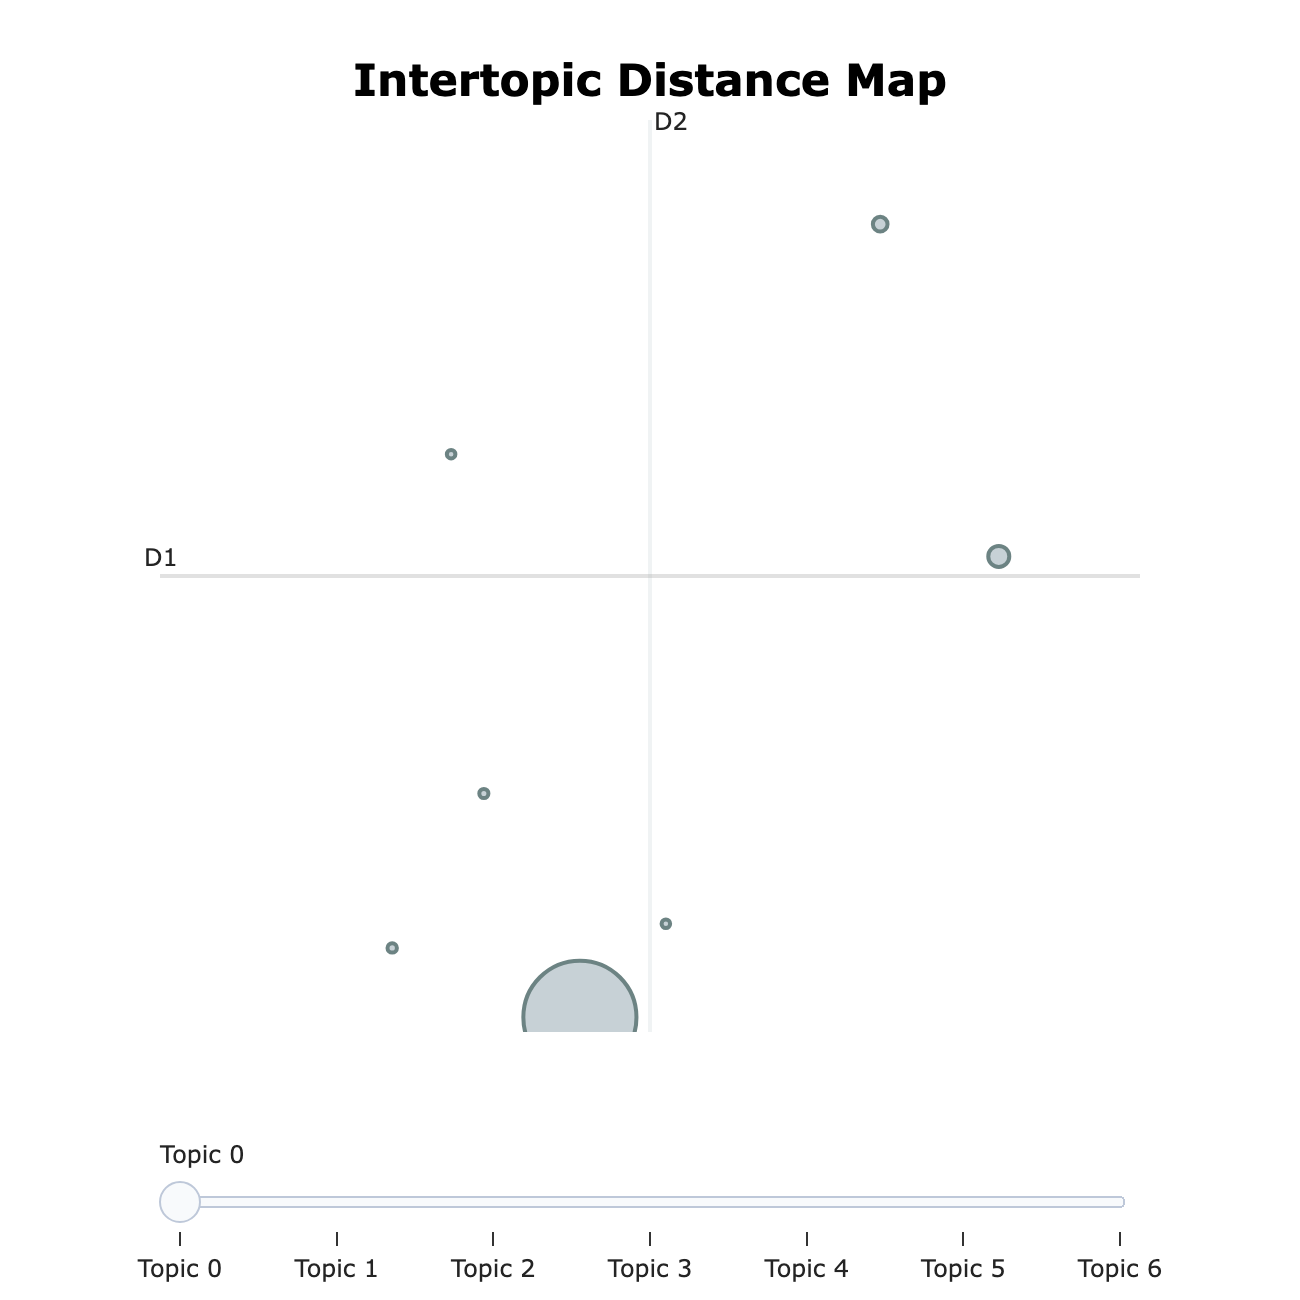

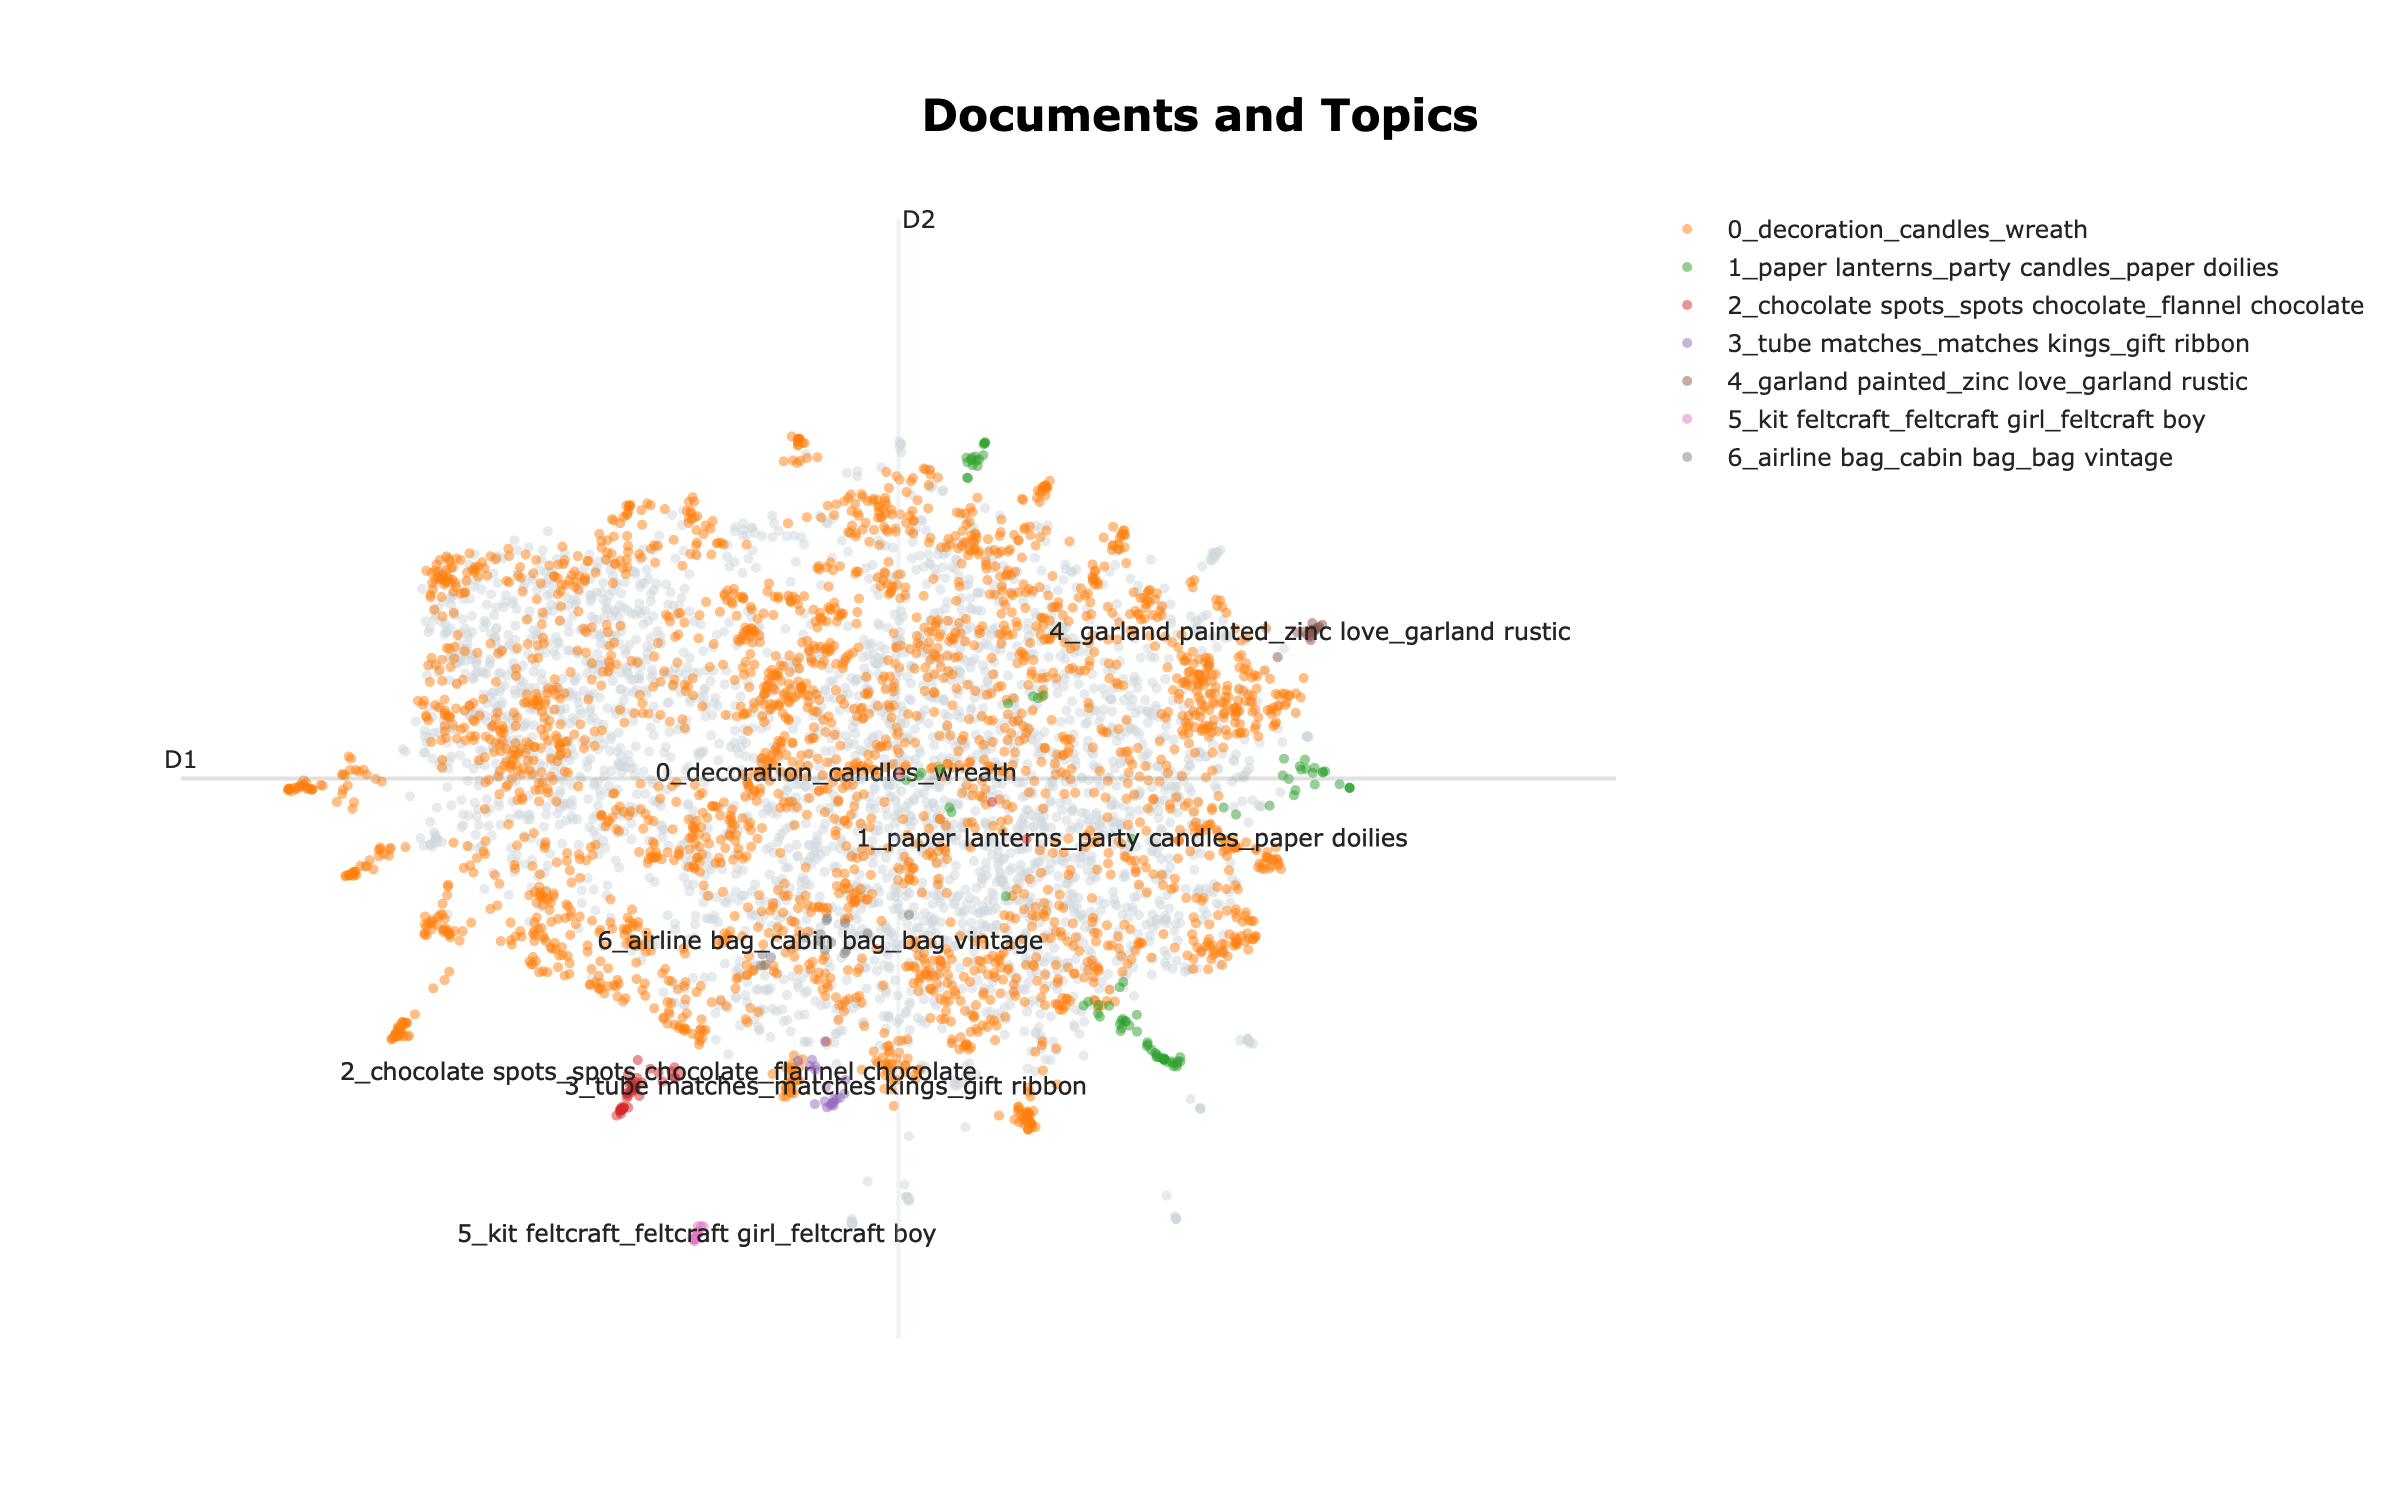

Saved umap_clusters.png to images/part4/sec4.1/


In [8]:
step("BERTopic visualizations: document scatter")

# 2D UMAP for visualize_documents
reduced_embeddings = UMAP(
    n_components=2, metric="cosine",
    random_state=CONFIG["random_state"], n_jobs=1,
).fit_transform(embeddings)

# Intertopic distance map (requires >= 3 topics)
if n_topics >= 3:
    fig_topics = topic_model.visualize_topics()
    fig_topics.show()
else:
    print(f"Skipping intertopic distance map (need >= 3 topics, got {n_topics})")

# Document scatter (main figure for the chapter)
fig_docs = topic_model.visualize_documents(
    customer_docs["doc"].tolist(),
    reduced_embeddings=reduced_embeddings,
    hide_document_hover=False,
)
fig_docs.show()

# Save static version for the book
try:
    fig_docs.write_image(_FIG_DIR / "umap_clusters.png",
                         width=1200, height=800, scale=2)
    print("Saved umap_clusters.png to images/part4/sec4.1/")
except (ValueError, OSError, ImportError) as e:
    # kaleido is required for static image export in the book build
    warnings.warn(f"Could not save static image (install kaleido): {e}")


  Step 6: BERTopic visualizations: hierarchy & barchart



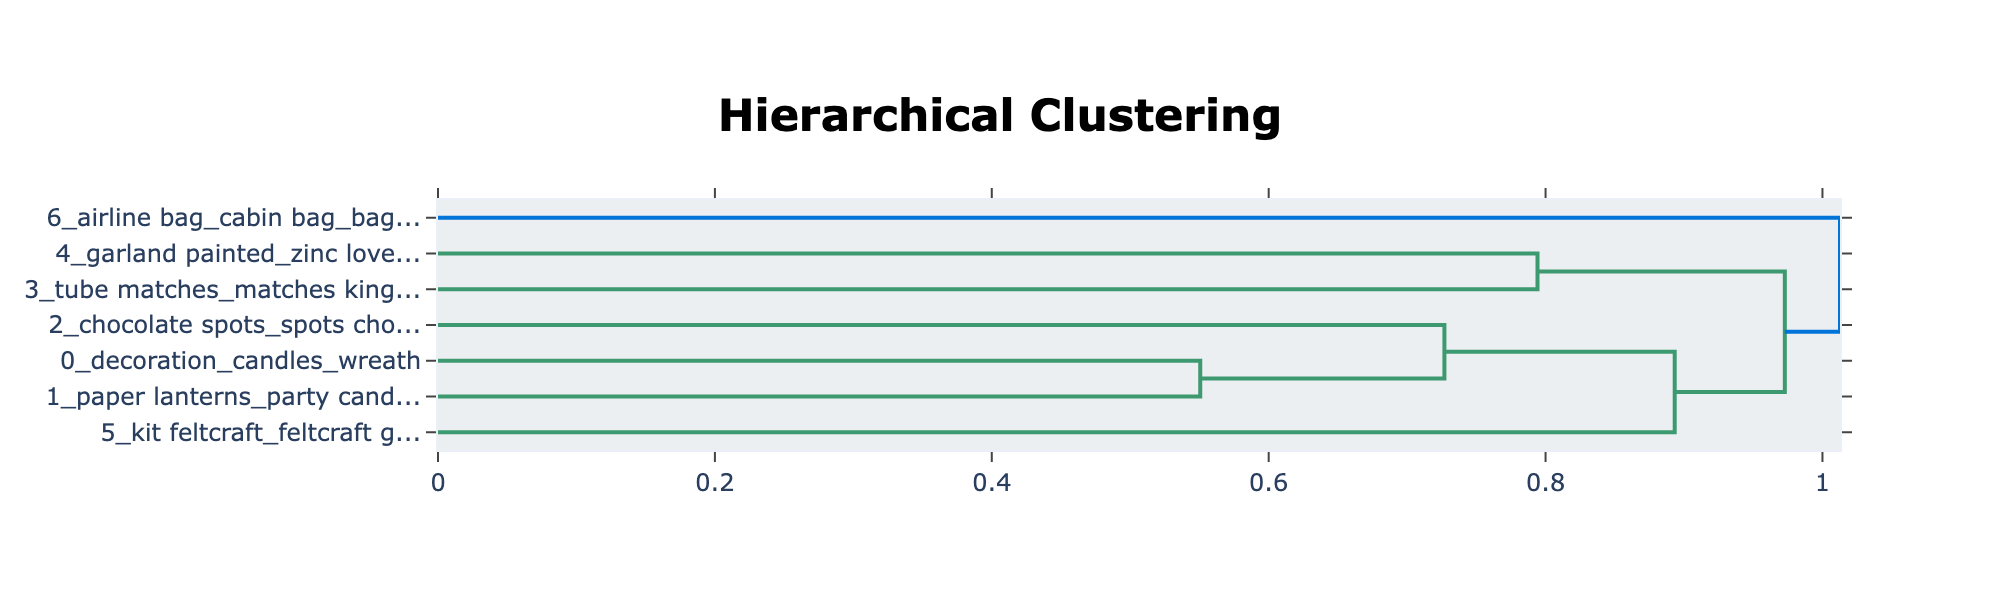

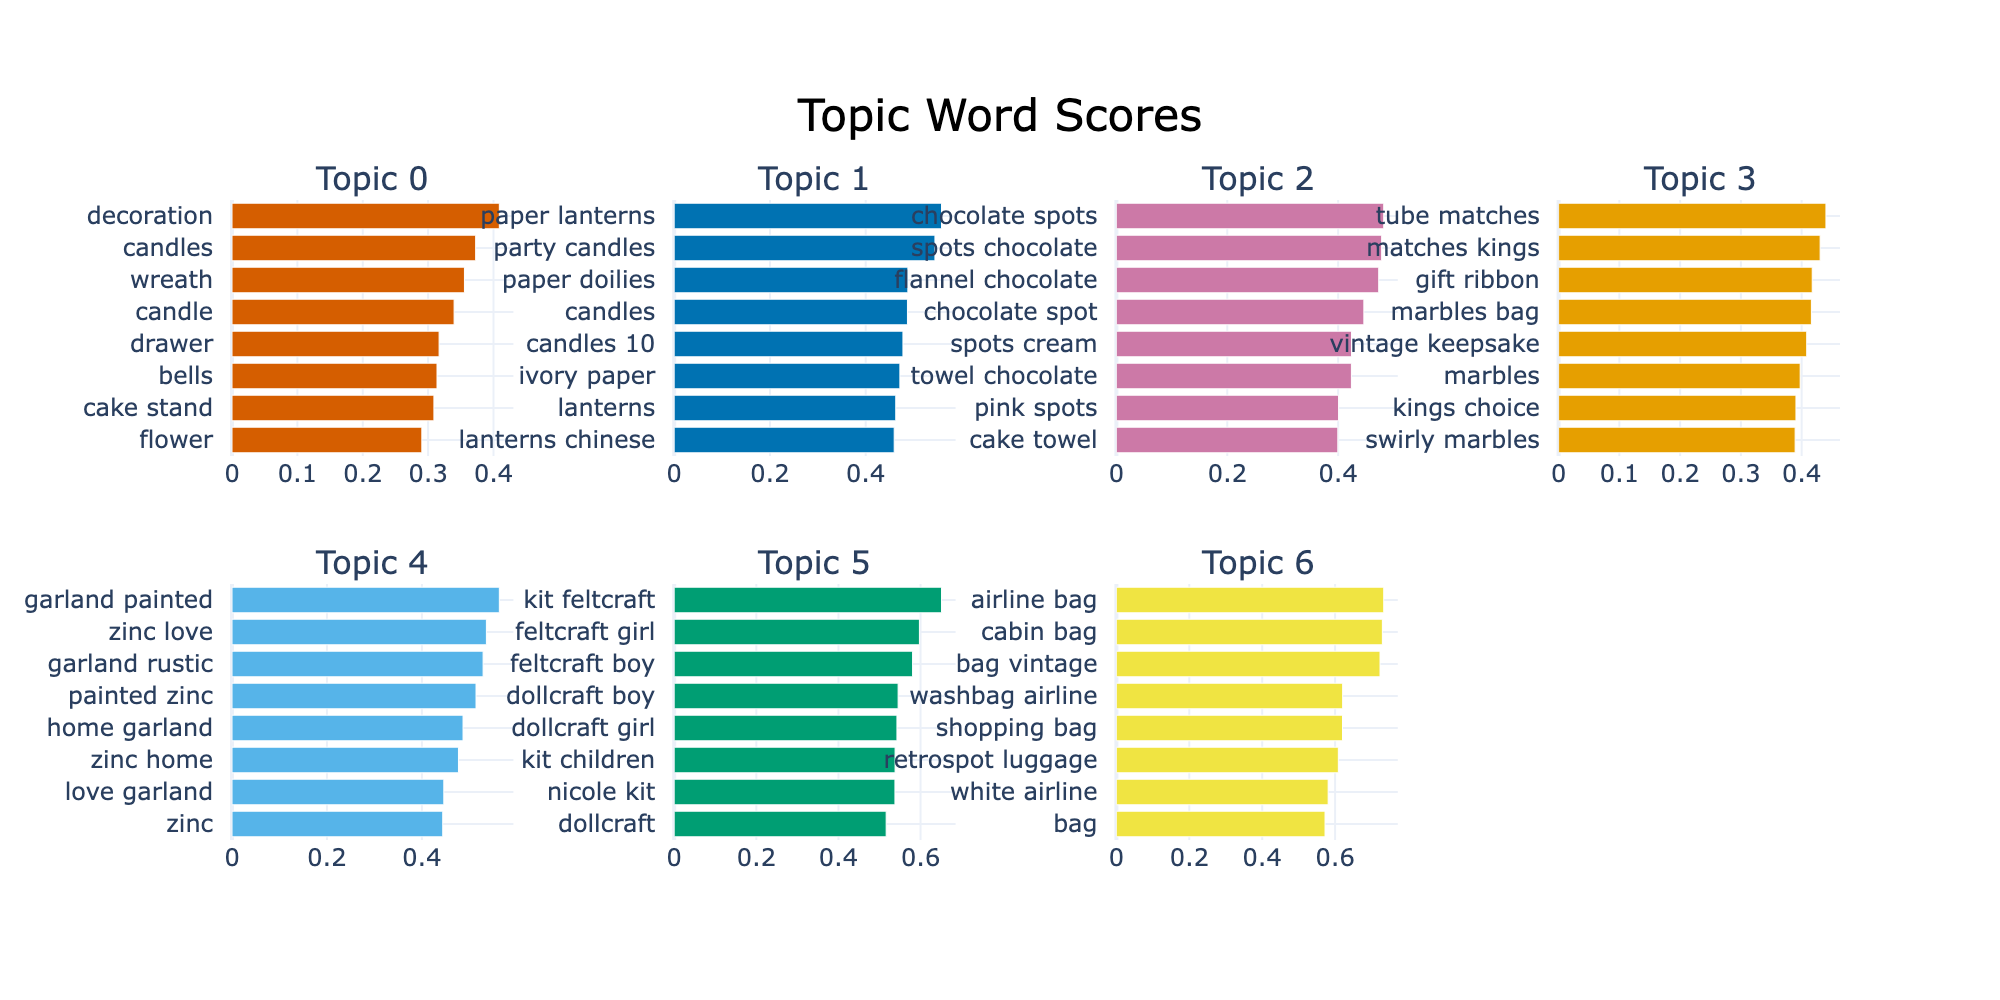

Saved hierarchy and barchart PNGs to images/part4/sec4.1/


In [9]:
step("BERTopic visualizations: hierarchy & barchart")

if n_topics >= 2:
    fig_hierarchy = topic_model.visualize_hierarchy()
    fig_hierarchy.show()

    fig_bar = topic_model.visualize_barchart(
        top_n_topics=min(8, n_topics), n_words=8
    )
    fig_bar.show()

    # Save static versions
    try:
        fig_hierarchy.write_image(
            _FIG_DIR / "bertopic_hierarchy.png",
            width=1200, height=600, scale=2)
        fig_bar.write_image(
            _FIG_DIR / "bertopic_barchart.png",
            width=1200, height=600, scale=2)
        print("Saved hierarchy and barchart PNGs to images/part4/sec4.1/")
    except (ValueError, OSError, ImportError) as e:
        # kaleido is required for static image export in the book build
        warnings.warn(f"Could not save static images (install kaleido): {e}")
else:
    print(f"Skipping hierarchy/barchart (need >= 2 topics, got {n_topics})")

## Outlier Reduction

HDBSCAN labels ambiguous customers as **noise** (topic = -1). Before
profiling, we reassign them using `reduce_outliers()` with the
**embeddings** strategy, which assigns each outlier to the topic whose
centroid is closest by cosine similarity in the original embedding space.

**Caution:** Outlier reduction tends to inflate the largest topic. When
one topic is already the broadest (most common product descriptions),
both c-TF-IDF and embedding-based strategies route most outliers there.
We show the result honestly, then compare with **KMeans** (below),
which produces balanced segments without noise.


In [10]:
step("Reduce outliers")

n_outliers_before = (np.array(topics) == -1).sum()

if n_outliers_before == 0:
    print("No outliers to reduce.")
else:
    # Use embeddings strategy: assigns each outlier to the topic whose
    # centroid is closest by cosine similarity.
    new_topics = topic_model.reduce_outliers(
        customer_docs["doc"].tolist(),
        topics,
        strategy="embeddings",
        embeddings=embeddings,
    )

    topic_model.update_topics(
        customer_docs["doc"].tolist(), topics=new_topics
    )
    topics = new_topics  # all subsequent cells use outlier-reduced topics
    n_outliers_after = (np.array(topics) == -1).sum()
    print(f"Outliers: {n_outliers_before:,} -> {n_outliers_after:,}")
    print(f"Reassigned: {n_outliers_before - n_outliers_after:,} customers")

    # Distribution after outlier reduction
    print("\nTopic sizes after outlier reduction:")
    sizes = pd.Series(topics).value_counts().sort_index()
    print(sizes)
    max_share = sizes.max() / len(topics)
    print(f"\nLargest topic: {sizes.idxmax()} with {sizes.max():,} customers "
          f"({max_share:.1%})")
    if max_share > 0.50:
        print("\n⚠ Mega-topic detected. HDBSCAN found one broad cluster that "
              "absorbed most outliers. This is a real finding: the majority of "
              "customers buy similar general-purpose products. The niche topics "
              "(parasols, war gliders, etc.) are genuine but too small for "
              "operational targeting. See the KMeans comparison below for "
              "balanced, actionable segments.")

2026-06-10 23:13:59,510 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.



  Step 7: Reduce outliers

Outliers: 2,764 -> 0
Reassigned: 2,764 customers

Topic sizes after outlier reduction:
0    5112
1     241
2      69
3      45
4      28
5      21
6      64
Name: count, dtype: int64

Largest topic: 0 with 5,112 customers (91.6%)

⚠ Mega-topic detected. HDBSCAN found one broad cluster that absorbed most outliers. This is a real finding: the majority of customers buy similar general-purpose products. The niche topics (parasols, war gliders, etc.) are genuine but too small for operational targeting. See the KMeans comparison below for balanced, actionable segments.


## Sub-decompose the mega-topic

When outlier reduction inflates one HDBSCAN topic past the 50% threshold
(the "mega-topic" the warning above flags), the chapter's 4–8
balanced-segments goal isn't reachable from HDBSCAN alone. We sub-cluster
**just the mega-topic's embeddings** with KMeans, splitting it into
several activation-sized segments while keeping the small niche topics
as discovery findings.

This is the chapter's "HDBSCAN for discovery, KMeans for operations"
pattern, applied surgically inside the dominant cluster instead of on
the full base.

In [11]:
step("Sub-decompose the mega-topic with KMeans")

_sizes = pd.Series(topics).value_counts()
_max_share = _sizes.iloc[0] / len(topics)
_mega_id = int(_sizes.idxmax()) if _max_share > CONFIG["mega_threshold"] else None

if _mega_id is None:
    print(f"No mega-topic detected (largest share {_max_share:.1%} ≤ "
          f"{CONFIG['mega_threshold']:.0%}). Keeping topics as-is.")
else:
    n_sub = CONFIG["mega_subsegments"]
    print(f"Mega-topic is Topic {_mega_id} "
          f"({_sizes.iloc[0]:,} customers, {_max_share:.1%}).")
    print(f"Sub-clustering into {n_sub} sub-segments with KMeans on embeddings.")

    mega_mask = (np.array(topics) == _mega_id)
    mega_embeddings = embeddings[mega_mask]
    sub_km = KMeans(
        n_clusters=n_sub,
        n_init=10,
        random_state=CONFIG["random_state"],
    )
    sub_labels = sub_km.fit_predict(mega_embeddings)

    # Build the new contiguous topic IDs:
    #   sub-segments of the former mega → 0 .. n_sub-1
    #   niches (original non-mega, non-noise topics) → n_sub .. end
    other_ids = sorted(t for t in set(topics) if t != _mega_id and t != -1)
    id_remap = {old: i + n_sub for i, old in enumerate(other_ids)}

    new_topics = np.full(len(topics), -1, dtype=int)
    new_topics[mega_mask] = sub_labels                       # 0..n_sub-1
    for old, new in id_remap.items():
        new_topics[np.array(topics) == old] = new            # n_sub..end

    final_n = n_sub + len(other_ids)
    print(f"\nFinal segmentation: {n_sub} sub-segments + "
          f"{len(other_ids)} niche topics = {final_n} total.")

    new_sizes = pd.Series(new_topics).value_counts().sort_index()
    print("\nNew topic sizes (≥10% floor passes if no ⚠):")
    for tid, n in new_sizes.items():
        share = n / len(new_topics)
        flag = "" if share >= CONFIG["min_segment_share"] else "  ⚠ < 10%"
        print(f"  Topic {tid}: {n:,} ({share:.1%}){flag}")

    # Push the new groupings into the BERTopic model so the LLM naming
    # cell below + the validation table both see them.
    topic_model.update_topics(
        customer_docs["doc"].tolist(),
        topics=new_topics.tolist(),
    )
    topics = new_topics


  Step 8: Sub-decompose the mega-topic with KMeans

Mega-topic is Topic 0 (5,112 customers, 91.6%).
Sub-clustering into 6 sub-segments with KMeans on embeddings.


2026-06-10 23:14:03,321 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.



Final segmentation: 6 sub-segments + 6 niche topics = 12 total.

New topic sizes (≥10% floor passes if no ⚠):
  Topic 0: 752 (13.5%)
  Topic 1: 681 (12.2%)
  Topic 2: 1,106 (19.8%)
  Topic 3: 366 (6.6%)  ⚠ < 10%
  Topic 4: 854 (15.3%)
  Topic 5: 1,353 (24.2%)
  Topic 6: 241 (4.3%)  ⚠ < 10%
  Topic 7: 69 (1.2%)  ⚠ < 10%
  Topic 8: 45 (0.8%)  ⚠ < 10%
  Topic 9: 28 (0.5%)  ⚠ < 10%
  Topic 10: 21 (0.4%)  ⚠ < 10%
  Topic 11: 64 (1.1%)  ⚠ < 10%


## LLM-Assisted Segment Naming

BERTopic's `representation_model` accepts LLM backends that turn c-TF-IDF
keyword bags into human-readable segment names. We route through
**litellm** so the provider string is the only thing that changes —
`anthropic/claude-haiku-4-5`, `openai/gpt-4o`, `ollama/llama3`, etc.

> **The LLM-naming trap.** Any LLM will produce a polished name for any
> cluster, including random noise. The validation cell below pairs every
> LLM-generated name with the underlying keyword/RFM evidence so you can
> check whether the narrative actually matches the data.

In [12]:
step("LLM-assisted topic naming")

from bertopic.representation import LiteLLM

SEGMENT_PROMPT = """You are a marketing analyst segmenting an online retail customer base.
Each "topic" below represents a customer segment defined by the products they buy.

Sample product descriptions from this segment:
[DOCUMENTS]

Keywords describing this segment: [KEYWORDS]

Based on the above, provide:
1. A short segment name (2-4 words)
2. A one-sentence marketing action

Format:
topic: <segment_name>, <marketing_action>"""

# Read the key from the environment — never hard-code.
_api_key = os.environ.get("ANTHROPIC_API_KEY")

if not _api_key:
    print(
        "ANTHROPIC_API_KEY not set in the environment. Skipping LLM naming.\n"
        "Falling back to c-TF-IDF keyword labels from the previous cells.\n"
        "Re-run with `export ANTHROPIC_API_KEY=...` to bake LLM names into "
        "this notebook."
    )
else:
    representation_model = LiteLLM(
        model=CONFIG["llm_model"],
        nr_docs=CONFIG["llm_nr_docs"],
        delay_in_seconds=CONFIG["llm_delay_seconds"],
        prompt=SEGMENT_PROMPT,
    )
    topic_model.update_topics(
        customer_docs["doc"].tolist(),
        representation_model=representation_model,
    )
    topic_info_llm = topic_model.get_topic_info()
    display(topic_info_llm[["Topic", "Count", "Name"]])


  Step 9: LLM-assisted topic naming



  0%|          | 0/12 [00:00<?, ?it/s]

  8%|▊         | 1/12 [00:02<00:28,  2.56s/it]

 17%|█▋        | 2/12 [00:04<00:23,  2.40s/it]

 25%|██▌       | 3/12 [00:07<00:20,  2.33s/it]

...

 83%|████████▎ | 10/12 [00:22<00:04,  2.21s/it]

 92%|█████████▏| 11/12 [00:25<00:02,  2.19s/it]

100%|██████████| 12/12 [00:27<00:00,  2.38s/it]

100%|██████████| 12/12 [00:27<00:00,  2.32s/it]

,Topic,Count,Name
0,0,752,"0_Festive Home Décor, Target email campaigns h..."
1,1,681,"1_Decorative Scented Candles, Target with cura..."
2,2,1106,"2_Retro Whimsical Gifting, Target with nostalg..."
3,3,366,"3_Vintage Home Décor, Target campaigns around ..."
4,4,854,"4_Vintage Home Décor Enthusiasts, develop a cu..."
5,5,1353,"5_Vintage Home Décor, Launch a curated gift co..."
6,6,241,"6_Party Decoration Essentials, Target budget-c..."
7,7,69,"7_Whimsical Spotted Homeware, Create a targete..."
8,8,45,"8_Vintage Novelty Essentials, Bundle Kings Cho..."
9,9,28,"9_Decorative Home Garland Enthusiasts, Target ..."


### Validate names against evidence (the LLM-naming trap)

For each segment we line up:

- the LLM-generated **Name** (or the c-TF-IDF fallback),
- the top 5 c-TF-IDF **keywords**,
- **median RFM** stats from the upstream feature table,
- the top 3 **products by revenue** for the segment.

A name that doesn't reflect the keywords or the RFM profile is a polished
fiction — replace it with the keyword bag and move on.

In [13]:
step("Validate LLM names against keyword + RFM evidence")

# Lock in topic-to-customer assignment for the validation table.
customer_docs["topic"] = topics
val_data = customer_docs.merge(uci_customers, on="CustomerID")
val_non_noise = val_data[val_data["topic"] != -1]

topic_info_validate = topic_model.get_topic_info()

print(f"\n{'Topic':<6}{'Name':<42}{'n':>6}  Top-5 keywords")
print("-" * 110)
for _, row in topic_info_validate.iterrows():
    t = row["Topic"]
    if t == -1:
        continue
    name = (row.get("Name") or "")[:40]
    n = int(row.get("Count") or (val_non_noise["topic"] == t).sum())
    kw = topic_model.get_topic(t)
    kw_str = ", ".join([w for w, _ in (kw or [])[:5]])
    print(f"{t:<6}{name:<42}{n:>6}  {kw_str}")

print("\nMedian RFM per topic (sanity-check the narrative):")
val_summary = (
    val_non_noise.groupby("topic")
    .agg(
        n=("CustomerID", "count"),
        med_recency=("recency", "median"),
        med_frequency=("frequency", "median"),
        med_monetary=("monetary", "median"),
    )
    .round(1)
)
val_summary["share_pct"] = (val_summary["n"] / val_summary["n"].sum() * 100).round(1)
display(val_summary)


  Step 10: Validate LLM names against keyword + RFM evidence


Topic Name                                           n  Top-5 keywords
--------------------------------------------------------------------------------------------------------------
0     0_Festive Home Décor, Target email campa     752  Festive Home Décor, Target email campaigns highlighting coordinated Christmas decoration sets and seasonal storage solutions to encourage bundle purchases and repeat seasonal buying.
1     1_Decorative Scented Candles, Target wit     681  Decorative Scented Candles, Target with curated candle gift sets and home décor bundles emphasizing premium packaging and ambient fragrance options.
2     2_Retro Whimsical Gifting, Target with n    1106  Retro Whimsical Gifting, Target with nostalgic home décor and playful accessories bundled as gift sets for customers seeking vintage-inspired items with personality.
3     3_Vintage Home Décor, Target campaigns a     366  Vintage Home Décor, Target campa

,n,med_recency,med_frequency,med_monetary,share_pct
topic,,,,,
0,752,64.50,3.00,828.20,13.50
1,681,185.00,3.00,593.00,12.20
2,1106,134.00,3.00,727.70,19.80
3,366,308.50,1.00,243.40,6.60
4,854,169.00,2.00,658.50,15.30
5,1353,30.00,10.00,4006.10,24.20
6,241,228.00,1.00,313.80,4.30
7,69,291.00,2.00,501.40,1.20
8,45,310.00,1.00,310.50,0.80



  Step 11: Statistical profiling per topic



,n_customers,avg_recency,med_recency,avg_frequency,med_frequency,avg_monetary,med_monetary,avg_products,med_products
topic,,,,,,,,,
0,752,167.80,64.50,4.10,3.00,1186.70,828.20,70.50,49.00
1,681,256.50,185.00,3.90,3.00,1171.00,593.00,58.00,40.00
2,1106,215.20,134.00,4.00,3.00,1477.60,727.70,66.60,47.00
3,366,306.30,308.50,2.00,1.00,695.60,243.40,12.30,10.00
4,854,225.70,169.00,3.30,2.00,1102.90,658.50,49.70,32.00
5,1353,88.40,30.00,15.70,10.00,8720.80,4006.10,189.50,142.00
6,241,270.40,228.00,2.50,1.00,1139.40,313.80,19.60,14.00
7,69,303.90,291.00,3.60,2.00,1017.80,501.40,39.70,23.00
8,45,310.50,310.00,1.70,1.00,447.00,310.50,17.40,14.00


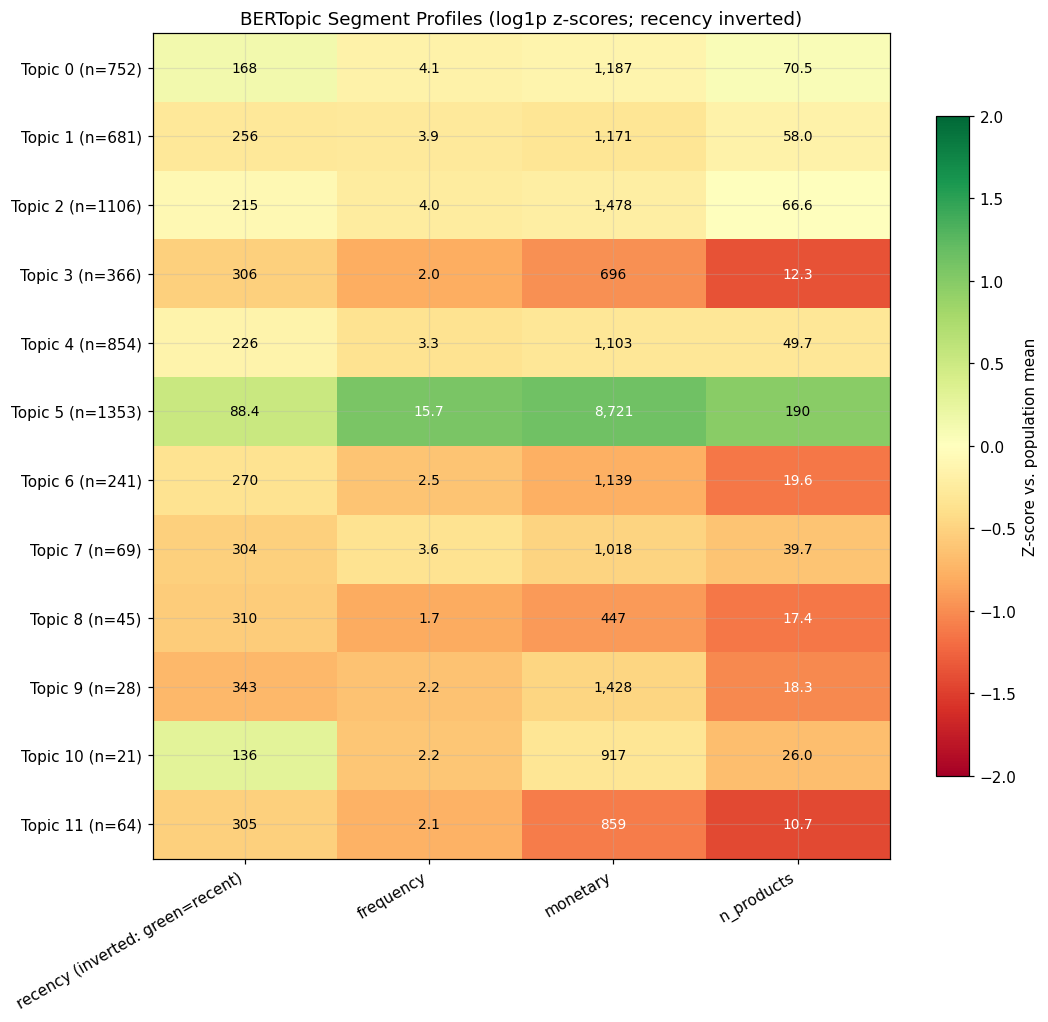


  Segment Cards

Summary:


,n_customers,share_pct,revenue,rev_share_pct,med_recency,med_frequency,med_aov
topic,,,,,,,
0,752,13.50,892403.00,5.30,64.50,3.00,273.40
1,681,12.20,797471.00,4.70,185.00,3.00,232.00
2,1106,19.80,1634250.00,9.70,134.00,3.00,262.10
3,366,6.60,254572.00,1.50,308.50,1.00,180.20
4,854,15.30,941850.00,5.60,169.00,2.00,253.10
5,1353,24.20,11799269.00,70.20,30.00,10.00,401.90
6,241,4.30,274594.00,1.60,228.00,1.00,192.60
7,69,1.20,70230.00,0.40,291.00,2.00,223.90
8,45,0.80,20115.00,0.10,310.00,1.00,194.30



--- Topic 0 ---
  Keywords: Festive Home Décor, Target email campaigns highlighting coordinated Christmas decoration sets and seasonal storage solutions to encourage bundle purchases and repeat seasonal buying.
  Top countries: United Kingdom (98%), Japan (1%), Sweden (1%)
  Top products:
    - WHITE HANGING HEART T-LIGHT HOLDER: £14,667
    - REGENCY CAKESTAND 3 TIER: £13,486
    - ASSORTED COLOUR BIRD ORNAMENT: £8,863
    - PAPER CHAIN KIT 50'S CHRISTMAS : £7,966
    - RABBIT NIGHT LIGHT: £7,797

--- Topic 1 ---
  Keywords: Decorative Scented Candles, Target with curated candle gift sets and home décor bundles emphasizing premium packaging and ambient fragrance options.
  Top countries: United Kingdom (99%), Germany (1%), Norway (1%)
  Top products:
    - REGENCY CAKESTAND 3 TIER: £32,689
    - WHITE HANGING HEART T-LIGHT HOLDER: £17,110
    - REGENCY TEAPOT ROSES : £8,283
    - SMALL POPCORN HOLDER: £7,644
    - POPCORN HOLDER: £7,433

--- Topic 2 ---
  Keywords: Retro Whimsical Gi

  Top countries: United Kingdom (89%), Channel Islands (8%), Belgium (3%)
  Top products:
    - PLASTERS IN TIN CIRCUS PARADE : £1,936
    - PLASTERS IN TIN STRONGMAN: £1,330
    - FELTCRAFT HAIRBAND PINK AND PURPLE: £565
    - FELTCRAFT GIRL NICOLE KIT: £520
    - FELTCRAFT GIRL AMELIE KIT: £496

--- Topic 11 ---
  Keywords: Vintage Travel Enthusiasts, cross-sell coordinated vintage-themed travel accessories (luggage tags, pouches, totes) that complement their airline bag purchases to increase basket size and create complete travel sets.
  Top countries: United Kingdom (97%), France (2%), Germany (1%)
  Top products:
    - SOMBRERO : £8,875
    - RED  HARMONICA IN BOX : £8,637
    - PAPER CHAIN KIT 50'S CHRISTMAS : £4,179
    - TRADITIONAL WOODEN SKIPPING ROPE: £4,074
    - GROW A FLYTRAP OR SUNFLOWER IN TIN: £3,155


In [14]:
step("Statistical profiling per topic")

# Merge topic assignments with RFM features
customer_docs["topic"] = topics
cluster_data = customer_docs.merge(uci_customers, on="CustomerID")

cluster_data.to_csv(_TABLES / "modern_topic_assignments.csv", index=False)

# Profile: RFM stats per topic (excluding noise if any remain)
non_noise = cluster_data[cluster_data["topic"] != -1]
if len(non_noise) == 0:
    print("No non-noise topics found. Skipping profiling.")
else:
    profile = (
        non_noise.groupby("topic")
        .agg(
            n_customers=("CustomerID", "count"),
            avg_recency=("recency", "mean"),
            med_recency=("recency", "median"),
            avg_frequency=("frequency", "mean"),
            med_frequency=("frequency", "median"),
            avg_monetary=("monetary", "mean"),
            med_monetary=("monetary", "median"),
            avg_products=("n_products", "mean"),
            med_products=("n_products", "median"),
        )
        .round(1)
    )
    profile.to_csv(_TABLES / "modern_segment_profile.csv", index=True)
    display(profile)

    # ── Heatmap with log-transformed z-scores (Issues 3, 7) ──
    avg_cols = ["avg_recency", "avg_frequency", "avg_monetary", "avg_products"]
    raw_cols = ["recency", "frequency", "monetary", "n_products"]
    skewed = {"frequency", "monetary", "n_products"}

    profile_z = pd.DataFrame(index=profile.index)
    for mc, rc in zip(avg_cols, raw_cols):
        # Population baseline and the per-segment mean must live in the SAME
        # space. For skewed columns we stay in log space throughout: taking
        # log1p of an already-averaged value (log of a mean) is not the mean of
        # the logs, and biases the z-score upward (Jensen's inequality).
        vals = cluster_data[rc].copy()
        if rc in skewed:
            vals = np.log1p(vals)
        pop_mean = vals.mean()
        pop_std = vals.std()
        seg_src = np.log1p(non_noise[rc]) if rc in skewed else non_noise[rc]
        seg_vals = seg_src.groupby(non_noise["topic"]).mean().reindex(profile.index)
        z = (seg_vals - pop_mean) / pop_std if pop_std > 0 else 0.0
        if rc == "recency":
            z = -z  # invert: green = recent (low days)
        profile_z[mc] = z

    x_labels = []
    for mc, rc in zip(avg_cols, raw_cols):
        label = rc
        if rc == "recency":
            label += " (inverted: green=recent)"
        x_labels.append(label)

    # Y-labels include customer count for readability
    y_labels = [f"Topic {t} (n={int(profile.loc[t, 'n_customers'])})"
                for t in profile.index]

    fig, ax = plt.subplots(figsize=(10, max(3, len(profile) * 0.7 + 1)))
    im = ax.imshow(profile_z.values, cmap="RdYlGn", aspect="auto", vmin=-2, vmax=2)
    ax.set_xticks(range(len(avg_cols)))
    ax.set_xticklabels(x_labels, rotation=30, ha="right")
    ax.set_yticks(range(len(profile)))
    ax.set_yticklabels(y_labels)

    for i in range(len(profile)):
        for j in range(len(avg_cols)):
            val = profile.iloc[i][avg_cols[j]]
            fmt = f"{val:,.0f}" if val > 100 else f"{val:.1f}"
            ax.text(j, i, fmt, ha="center", va="center", fontsize=9,
                    color="white" if abs(profile_z.iloc[i, j]) > 1 else "black")

    fig.colorbar(im, ax=ax, label="Z-score vs. population mean", shrink=0.8)
    ax.set_title("BERTopic Segment Profiles (log1p z-scores; recency inverted)")
    fig.tight_layout()
    savefig(fig, "bertopic_segment_heatmap.png")
    plt.show()

    # ── Guardrail: warn if any topic > 50% ──
    topic_sizes = non_noise["topic"].value_counts()
    max_share = topic_sizes.max() / len(non_noise)
    if max_share > 0.50:
        print(f"\n{'!'*60}")
        print(f"  WARNING: Topic {topic_sizes.idxmax()} contains {max_share:.0%} "
              f"of customers (mega-topic).")
        print(f"  Suggestions:")
        print(f"    - Increase min_cluster_size (currently {CONFIG['min_cluster_size']})")
        print(f"    - Tighten generic_product_threshold (currently {CONFIG['generic_product_threshold']})")
        print(f"    - Use KMeans on embeddings for balanced segments")
        print(f"{'!'*60}\n")

    # ── Segment Card: summary + per-topic detail ──
    print("\n" + "="*60)
    print("  Segment Cards")
    print("="*60)

    # Summary table
    summary = profile[["n_customers"]].copy()
    summary["share_pct"] = (summary["n_customers"] / summary["n_customers"].sum() * 100).round(1)
    summary["revenue"] = non_noise.groupby("topic")["monetary"].sum().round(0)
    summary["rev_share_pct"] = (summary["revenue"] / summary["revenue"].sum() * 100).round(1)
    summary["med_recency"] = profile["med_recency"]
    summary["med_frequency"] = profile["med_frequency"]
    summary["med_aov"] = non_noise.groupby("topic")["avg_order_value"].median().round(1)
    print("\nSummary:")
    display(summary)

    # Per-topic detail cards
    for t in sorted(non_noise["topic"].unique()):
        if t == -1:
            continue
        print(f"\n--- Topic {t} ---")

        # Top 5 keywords
        kw = topic_model.get_topic(t)
        if kw:
            kw_str = ", ".join([w for w, _ in kw[:5]])
            print(f"  Keywords: {kw_str}")

        # Top 3 countries
        seg_cids = set(non_noise[non_noise["topic"] == t]["CustomerID"])
        seg_raw = raw[raw["CustomerID"].isin(seg_cids)]
        top_countries = seg_raw.groupby("Country")["Revenue"].sum().nlargest(3)
        country_str = ", ".join(
            [f"{c} ({v/top_countries.sum():.0%})" for c, v in top_countries.items()]
        )
        print(f"  Top countries: {country_str}")

        # Top 5 products by revenue
        top_prods = (seg_raw.groupby("Description")["Revenue"]
                     .sum().nlargest(5))
        print(f"  Top products:")
        for desc, rev in top_prods.items():
            print(f"    - {desc}: £{rev:,.0f}")

## HDBSCAN vs. KMeans: Discovery vs. Operations

HDBSCAN finds **density-based niches**: sharp, well-separated groups
(parasols, war gliders) plus a large noise cluster. This is great for
*discovery* — finding segments you didn't know existed. But it often
produces **unbalanced** results: one mega-topic absorbs the majority of
customers, while niche topics have 10-150 each. That's hard to act on.

**KMeans on the same embeddings** gives balanced, actionable segments.
Every customer gets assigned (no noise), and cluster sizes are roughly
equal. The tradeoff: KMeans forces boundaries where HDBSCAN would leave
ambiguity, so borderline customers may be misassigned.

**Practical guidance:** Use HDBSCAN for exploratory analysis (what niches
exist?), then KMeans for operational targeting (assign every customer to
a segment for campaign execution).


In [15]:
step("KMeans on embeddings: balanced alternative")

# ── KMeans on the same UMAP-reduced embeddings ──
# UMAP first (same settings as BERTopic), then KMeans for balanced clusters.
umap_for_km = UMAP(
    n_components=CONFIG["umap_n_components"],
    metric="cosine",
    random_state=CONFIG["random_state"],
    n_jobs=1,
).fit_transform(embeddings)

km = KMeans(n_clusters=CONFIG["kmeans_k"], n_init=10,
            random_state=CONFIG["random_state"])
km_labels = km.fit_predict(umap_for_km)

# Compare distributions
print("BERTopic final segment sizes (after mega-split):")
final_topics = np.array(topics)
bertopic_sizes = pd.Series(final_topics).value_counts().sort_index()
print(bertopic_sizes)
print(f"\nBERTopic largest segment: {bertopic_sizes.max()} "
      f"({bertopic_sizes.max() / len(final_topics):.1%})")

print("\nKMeans cluster sizes:")
km_sizes = pd.Series(km_labels).value_counts().sort_index()
print(km_sizes)
print(f"\nKMeans largest cluster: {km_sizes.max()} "
      f"({km_sizes.max() / len(km_labels):.1%})")

# Silhouette on the SAME customers, SAME (original) embedding space, for the
# FINAL labels of both pipelines. The earlier `sil` was the initial HDBSCAN
# pass (82 topics, non-noise only) and is not comparable to either of these.
_mask = final_topics != -1
sil_final = silhouette_score(embeddings[_mask], final_topics[_mask], metric="cosine")
sil_km = silhouette_score(embeddings[_mask], km_labels[_mask], metric="cosine")
print(f"\nSilhouette (cosine, same {int(_mask.sum()):,} customers): "
      f"BERTopic final={sil_final:.3f}  KMeans={sil_km:.3f}")

bt_top = pd.Series(final_topics[_mask]).value_counts(normalize=True).iloc[0]
km_top = pd.Series(km_labels[_mask]).value_counts(normalize=True).iloc[0]
if max(sil_final, sil_km) < 0.10:
    print(f"Both silhouettes are near zero — neither clustering is 'tight' in "
          f"embedding space. KMeans wins on balance (largest cluster "
          f"{km_top:.0%} vs {bt_top:.0%}), not on cohesion.")
elif sil_km >= sil_final:
    print(f"KMeans is at least as cohesive ({sil_km:.3f} vs {sil_final:.3f}) "
          f"and more balanced (largest cluster {km_top:.0%} vs {bt_top:.0%}).")
else:
    print(f"BERTopic's final segments are more cohesive ({sil_final:.3f} vs "
          f"{sil_km:.3f}); KMeans still wins on balance "
          f"({km_top:.0%} vs {bt_top:.0%}).")

km_comparison = pd.DataFrame({
    "CustomerID": customer_docs["CustomerID"].values,
    "hdbscan_topic": topics,
    "kmeans_cluster": km_labels,
})
km_comparison.to_csv(_TABLES / "modern_hdbscan_vs_kmeans.csv", index=False)


  Step 12: KMeans on embeddings: balanced alternative



BERTopic final segment sizes (after mega-split):
0      752
1      681
2     1106
3      366
4      854
5     1353
6      241
7       69
8       45
9       28
10      21
11      64
Name: count, dtype: int64

BERTopic largest segment: 1353 (24.2%)

KMeans cluster sizes:
0     757
1    1276
2     749
3     469
4     810
5    1004
6     515
Name: count, dtype: int64

KMeans largest cluster: 1276 (22.9%)



Silhouette (cosine, same 5,580 customers): BERTopic final=0.031  KMeans=-0.001
Both silhouettes are near zero — neither clustering is 'tight' in embedding space. KMeans wins on balance (largest cluster 23% vs 24%), not on cohesion.


## Activate: Scoring New Customers

BERTopic's `transform()` method scores new documents against the fitted model
without refitting. This replaces the manual `UMAP.transform()` →
`hdbscan.approximate_predict()` chain with a single call.

**One catch after relabeling.** We reassigned segment IDs by hand with
`update_topics(topics=...)` in the mega-split above, but that call does *not*
update the model's internal `topic_mapper_`. So `transform()` keeps returning
IDs in the model's *original* space (where the mega-topic is still one big
cluster), not the final segment IDs the cards and heatmap use. In production
you must translate the model-space ID into a final segment ID — exactly what
the mapping below does: sub-classify a mega hit with the same KMeans that
split it, and look up a niche hit in the remap table.

In [16]:
step("Score a new (held-out) customer with transform()")

# HDBSCAN's transform() can return -1 for documents that don't fall in a
# dense embedding region. The chapter point is that *some* customer must
# get a real topic for the demo to land. We pick the customer whose document
# is closest to a topic centroid by trying a few candidates and selecting
# the first non-noise assignment.

# Candidate pool: customers in the final-space niche segments (IDs >=
# mega_subsegments). These map back to small, focused model-space topics, so
# transform() is most likely to land cleanly on them. The mega-derived
# sub-segments (IDs 0..mega_subsegments-1) all collapse to one model-space
# topic, which makes them weaker demo candidates.
_assigned = pd.Series(topics, index=customer_docs.index)
if _mega_id is not None:
    small_topics = [t for t in set(topics) if t >= CONFIG["mega_subsegments"]]
else:
    small_topics = [t for t in set(topics) if t != -1]
if not small_topics:
    small_topics = [t for t in set(topics) if t != -1]

candidate_cids = []
for t in small_topics:
    candidate_cids.extend(
        customer_docs.loc[_assigned == t, "CustomerID"].tolist()[:5]
    )
# Fallback: any non-noise customer
if not candidate_cids:
    candidate_cids = customer_docs.loc[_assigned != -1, "CustomerID"].tolist()[:10]

def to_final_segment(raw_topic, doc):
    """Translate a model-space topic ID (what transform() returns) into the
    final segment ID used by the cards and the heatmap."""
    if _mega_id is None:
        return raw_topic                          # no relabeling happened
    if raw_topic == _mega_id:
        doc_emb = embedding_model.encode([doc])   # sub_km lives in the raw
        return int(sub_km.predict(doc_emb)[0])     # embedding space -> 0..n_sub-1
    if raw_topic in id_remap:
        return id_remap[raw_topic]                # niche hit -> n_sub..
    return raw_topic                              # -1 or already final


demo_cid = None
demo_doc = None
raw_topic = -1
final_topic = -1
demo_prob = 0.0
for cid in candidate_cids:
    doc = customer_docs.loc[customer_docs["CustomerID"] == cid, "doc"].iloc[0]
    tt, pp = topic_model.transform([doc])      # <- model-space (pre-relabel) ID
    if tt[0] != -1:
        demo_cid, demo_doc, raw_topic = cid, doc, int(tt[0])
        if pp is not None and len(pp) > 0:
            pv = pp[0]
            demo_prob = float(np.max(pv)) if hasattr(pv, "__len__") else float(pv)
        final_topic = to_final_segment(raw_topic, demo_doc)
        break

if demo_cid is None:
    # No candidate landed on a non-noise topic — surface this honestly.
    cid = candidate_cids[0]
    demo_doc = customer_docs.loc[customer_docs["CustomerID"] == cid, "doc"].iloc[0]
    demo_cid = cid
    print(f"Held-out customer (CustomerID={demo_cid}):")
    print(f"  document (head): {demo_doc[:160]}...")
    print("  model-space topic: -1 (HDBSCAN outlier)")
    print(
        "\n⚠ transform() returned -1 for every candidate. In production, fall "
        "back to the KMeans-on-embeddings comparison below — KMeans assigns "
        "every customer to a segment by construction."
    )
else:
    stored = customer_docs.loc[
        customer_docs["CustomerID"] == demo_cid, "topic"
    ].iloc[0]
    print(f"Held-out customer (CustomerID={demo_cid}):")
    print(f"  document (head):    {demo_doc[:160]}...")
    print(f"  model-space topic:  {raw_topic}  (raw transform() output, pre-relabel)")
    print(f"  final segment:      {final_topic}  (after model-space -> final mapping)")
    print(f"  stored segment:     {int(stored)}  (this customer's card assignment)")
    print(f"  probability:        {demo_prob:.3f}")
    print(
        "\nThe final segment is what you match against the cards and heatmap. It "
        "usually equals the stored segment; transform() is an approximation, so "
        "an occasional mismatch is expected. transform() can also return -1 for "
        "genuinely off-pattern customers — the KMeans pass below is the "
        "production-side fallback that always assigns a segment."
    )


  Step 13: Score a new (held-out) customer with transform()



Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2026-06-10 23:14:39,709 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.


2026-06-10 23:14:46,632 - BERTopic - Dimensionality - Completed ✓


2026-06-10 23:14:46,632 - BERTopic - Clustering - Approximating new points with `hdbscan_model`


2026-06-10 23:14:46,634 - BERTopic - Cluster - Completed ✓


Held-out customer (CustomerID=12363):
  document (head):    /10 ivory polkadot party candles, /10 ivory polkadot party candles, of 36 mushroom paper doilies, of 72 skull paper doilies, doormat welcome sunrise...
  model-space topic:  1  (raw transform() output, pre-relabel)
  final segment:      6  (after model-space -> final mapping)
  stored segment:     6  (this customer's card assignment)
  probability:        0.690

The final segment is what you match against the cards and heatmap. It usually equals the stored segment; transform() is an approximation, so an occasional mismatch is expected. transform() can also return -1 for genuinely off-pattern customers — the KMeans pass below is the production-side fallback that always assigns a segment.


## Traditional vs. Embedding Stability Comparison

We split the data into two time halves, run K-Means on RFM features and
embedding-based clustering (UMAP + HDBSCAN) on customer documents for
each half, then compare ARI to see which approach produces more temporally
stable segments.

In [17]:
step("Traditional vs. Embedding stability (ARI comparison)")

import gc

# Split data at the midpoint
mid_date = raw["InvoiceDate"].min() + (
    raw["InvoiceDate"].max() - raw["InvoiceDate"].min()
) / 2
raw_h1 = raw[raw["InvoiceDate"] <= mid_date]
raw_h2 = raw[raw["InvoiceDate"] > mid_date]

# Customers present in both halves
cust_h1 = set(raw_h1["CustomerID"].unique())
cust_h2 = set(raw_h2["CustomerID"].unique())
common_cust = sorted(cust_h1 & cust_h2)
print(f"Customers in both halves: {len(common_cust):,}")

# --- Traditional: K-Means on RFM features ---
def compute_rfm(df, ref):
    return (
        df.groupby("CustomerID")
        .agg(
            recency=("InvoiceDate", lambda x: (ref - x.max()).days),
            frequency=("Invoice", "nunique"),
            monetary=("Revenue", "sum"),
        )
        .reset_index()
    )

rfm_h1 = compute_rfm(raw_h1, mid_date).set_index("CustomerID").loc[common_cust]
rfm_h2 = compute_rfm(
    raw_h2, raw["InvoiceDate"].max() + pd.Timedelta(days=1)
).set_index("CustomerID").loc[common_cust]

X_h1 = StandardScaler().fit_transform(rfm_h1)
X_h2 = StandardScaler().fit_transform(rfm_h2)

km_labels_h1 = KMeans(n_clusters=4, n_init=10, random_state=42).fit_predict(X_h1)
km_labels_h2 = KMeans(n_clusters=4, n_init=10, random_state=42).fit_predict(X_h2)
ari_kmeans_all = adjusted_rand_score(km_labels_h1, km_labels_h2)

# --- Embedding: UMAP + HDBSCAN on customer docs ---
def build_docs(df, cust_list, top_n=20):
    pr = (
        df[df["CustomerID"].isin(cust_list)]
        .groupby(["CustomerID", "Description"])["Revenue"]
        .sum()
        .reset_index()
        .sort_values(["CustomerID", "Revenue"], ascending=[True, False])
        .groupby("CustomerID")
        .head(top_n)
    )
    return (
        pr.groupby("CustomerID")["Description"]
        .apply(lambda x: ", ".join(x))
        .reindex(cust_list)
        .fillna("")
        .tolist()
    )

docs_h1 = build_docs(raw_h1, common_cust)
docs_h2 = build_docs(raw_h2, common_cust)

# Encode and cluster each half (using raw UMAP+HDBSCAN to save memory)
emb_h1 = embedding_model.encode(docs_h1, show_progress_bar=False)
emb_h2 = embedding_model.encode(docs_h2, show_progress_bar=False)

umap_h1 = UMAP(
    n_components=CONFIG["umap_n_components"], metric="cosine",
    random_state=42, n_jobs=1,
).fit_transform(emb_h1)
umap_h2 = UMAP(
    n_components=CONFIG["umap_n_components"], metric="cosine",
    random_state=42, n_jobs=1,
).fit_transform(emb_h2)

embed_labels_h1 = HDBSCAN(
    min_cluster_size=CONFIG["min_cluster_size"],
    min_samples=CONFIG["min_samples"],
).fit_predict(umap_h1)
embed_labels_h2 = HDBSCAN(
    min_cluster_size=CONFIG["min_cluster_size"],
    min_samples=CONFIG["min_samples"],
).fit_predict(umap_h2)

# Free memory
del emb_h1, emb_h2, umap_h1, umap_h2
gc.collect()

# Fair comparison (Issue 5): apply same non-noise filter to both methods
valid = (embed_labels_h1 != -1) & (embed_labels_h2 != -1)
if valid.sum() > 0:
    ari_kmeans_fair = adjusted_rand_score(
        km_labels_h1[valid], km_labels_h2[valid]
    )
    ari_embed = adjusted_rand_score(
        embed_labels_h1[valid], embed_labels_h2[valid]
    )
else:
    ari_kmeans_fair = float("nan")
    ari_embed = float("nan")

print(f"\n{'---'*17}")
print(f"  Temporal Stability (ARI)")
print(f"{'---'*17}")
print(f"  K-Means (all customers):       {ari_kmeans_all:.3f}")
print(f"  K-Means (same non-noise set):  {ari_kmeans_fair:.3f}")
print(f"  Embedding (non-noise set):     {ari_embed:.3f}")
print(f"  Non-noise pairs:               {valid.sum():,} / {len(common_cust):,}")

# Data-driven reading: let the numbers, not a hard-coded sentence, set tone.
def _ari_label(x):
    if not np.isfinite(x): return "undefined"
    if x < 0.05:           return "essentially none (near zero)"
    if x < 0.15:           return "weak"
    if x < 0.35:           return "modest"
    return "moderate-to-strong"

gap = (ari_embed - ari_kmeans_fair) if np.isfinite(ari_embed) and np.isfinite(ari_kmeans_fair) else float("nan")
if not np.isfinite(gap):
    verdict = "the comparison is undefined for this slice"
elif abs(gap) < 0.03:
    verdict = "the two methods are essentially tied on temporal stability"
elif gap > 0:
    verdict = (
        f"the embedding pipeline is more temporally stable than RFM-KMeans "
        f"on the same non-noise set (Δ = +{gap:.3f})"
    )
else:
    verdict = (
        f"RFM-KMeans is more temporally stable than the embedding pipeline "
        f"on the same non-noise set (Δ = {gap:.3f})"
    )

print()
print(
    "Reading: K-Means stability on the full base is "
    f"**{_ari_label(ari_kmeans_all)}** (ARI {ari_kmeans_all:.3f}); on the same "
    f"non-noise set it is **{_ari_label(ari_kmeans_fair)}** "
    f"(ARI {ari_kmeans_fair:.3f}). The embedding pipeline scores "
    f"**{_ari_label(ari_embed)}** (ARI {ari_embed:.3f}). So {verdict}."
)
print(
    "Either way, embeddings track seasonal product mix, so the persistent "
    "customer ID in the CRM is best derived from RFM-KMeans, with the "
    "embedding pass kept for discovery and re-run on a refresh schedule."
)


  Step 14: Traditional vs. Embedding stability (ARI comparison)

Customers in both halves: 2,706



---------------------------------------------------
  Temporal Stability (ARI)
---------------------------------------------------
  K-Means (all customers):       0.138
  K-Means (same non-noise set):  0.136
  Embedding (non-noise set):     0.001
  Non-noise pairs:               1,485 / 2,706

Reading: K-Means stability on the full base is **weak** (ARI 0.138); on the same non-noise set it is **weak** (ARI 0.136). The embedding pipeline scores **essentially none (near zero)** (ARI 0.001). So RFM-KMeans is more temporally stable than the embedding pipeline on the same non-noise set (Δ = -0.136).
Either way, embeddings track seasonal product mix, so the persistent customer ID in the CRM is best derived from RFM-KMeans, with the embedding pass kept for discovery and re-run on a refresh schedule.


In [18]:
step("Save BERTopic model")

save_dir = "bertopic_customer_segments"
try:
    topic_model.save(
        save_dir,
        serialization="safetensors",
        save_ctfidf=True,
        save_embedding_model=CONFIG["embedding_model"],
    )
    print(f"Model saved to ./{save_dir}/")
    print(f"Reload with: BERTopic.load('{save_dir}')")
except Exception as e:
    print(f"Save failed: {e}")
    print("You can still use the model in this session.")


  Step 15: Save BERTopic model

Model saved to ./bertopic_customer_segments/
Reload with: BERTopic.load('bertopic_customer_segments')


## Key Takeaways

1. **Embeddings add purchase meaning that RFM-KMeans cannot.** Two
   customers with similar spend, frequency, and recency can buy very
   different things; the embedding pipeline picks up that signal.
2. **Document construction matters more than the embedding model.**
   Filter ubiquitous SKUs (>5% of customers), revenue-weight the top-N
   products, and normalize descriptions before encoding.
3. **Discovery vs. activation.** HDBSCAN finds sharp niches; collapse
   them to 4–8 segments with `reduce_topics()` (or use KMeans on the
   same embeddings) for a CRM-ready segmentation.
4. **The LLM-naming trap.** An LLM will name any cluster, including
   noise. Always pair the generated name with keyword + RFM evidence;
   if the narrative doesn't match the data, keep the keyword label.
5. **`transform()` is the activation hook.** Score held-out customers
   against the saved model, and fall back to KMeans-on-embeddings when
   HDBSCAN flags the customer as an outlier.
6. **Be honest about temporal stability.** ARI on the time-split halves
   is the right diagnostic, and the verdict depends on the run.
   Embeddings track seasonal product mix; either re-embed on a known
   schedule or use the embedding for discovery and an RFM-KMeans
   segment for the persistent CRM ID.